# Evaluacion Final — Matemática Numérica
## Universidad de La Habana · MATCOM · Ciencia de Datos
### Curso 2024–2025

---

**Modalidad:** Tarea en casa &nbsp;&nbsp;|&nbsp;&nbsp; **Fecha de entrega:** 17 de junio de 2026

> **Instrucciones generales**
> 1. Resuelva los ejercicios en este notebook. Complete las celdas de codigo donde aparece `# su codigo aquí`.
> 2. Los ejercicios marcados como *teoricos* pueden desarrollarse con **lápiz y papel**. Adjunte el desarrollo (foto o escaneo) **dentro del mismo comprimido** (.zip) que entregue junto con el notebook.
> 3. **Prohibido** usar `numpy.linalg.inv` para resolver sistemas lineales; use `numpy.linalg.solve` o sustitucion directa.
> 4. Se permite el uso de documentacion oficial, apuntes y recursos bibliográficos.
> 5. Los **Ejercicios Extra** no son necesarios para aprobar, pero son **imprescindibles** para alcanzar la calificacion de 4 o 5. Sin ellos no se puede obtener la nota máxima.

| Ejercicio | Tema |
|-----------|------|
| 1 | Aritmética de Punto Flotante (IEEE 754) |
| 2a | Sistemas Lineales — Teorico (LU, lápiz/papel) |
| 2b | Sistemas Lineales — Práctico (problema real 3×3) |
| 3 | Ecuacion No Lineal (Newton/scipy) |
| 4 | Interpolacion (Lagrange + Splines cúbicos) |
| 5 | Regresion Lineal (1 y 2 variables) |
| Extra 1 ⭐ | Método de Newton desde cero |
| Extra 2 ⭐ | Regresion lineal *n* variables desde cero |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate, optimize
import struct, math, warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

---
## Ejercicio 1 — Aritmética de Punto Flotante

### Recordatorio: IEEE 754 de precision simple

El estandar IEEE 754 de **precision simple** (32 bits) codifica un número real como:

$$(-1)^s \times 2^{\,e - 127} \times (1.m)_2$$

| Campo | Bits | Significado |
|-------|------|-------------|
| Signo $s$ | 1 | 0 = positivo, 1 = negativo |
| Exponente $e$ | 8 | Valor almacenado = exp. real + **127** (sesgo) |
| Mantisa $m$ | 23 | Fraccion después del **1 implícito** |

El **épsilon de máquina** en precision simple es $\varepsilon_M = 2^{-23} \approx 1.19 \times 10^{-7}$.

Los **errores de redondeo** se miden con:
$$E_{\text{abs}} = |p^* - p|, \qquad E_{\text{rel}} = \frac{|p^* - p|}{|p|}$$

La **cancelacion catastrofica** ocurre al restar dos números casi iguales: los dígitos significativos se anulan y el error relativo del resultado se dispara .

### Parte a — Representacion IEEE 754 &nbsp;*(teorico + verificacion)*

> 📝 Esta parte puede desarrollarse con **lápiz y papel**. Adjunte su desarrollo al comprimido de entrega.

Represente el número $-13.625$ en IEEE 754 de precision simple.

**Pasos sugeridos:**
1. Convierta la parte entera: $13 = (1101)_2$
2. Convierta la parte decimal: $0.625 = (0.101)_2$
3. Normalice: $13.625 = (1101.101)_2 = 1.101101 \times 2^3$
4. Bit de signo, exponente almacenado ($3+127=130$) y mantisa en 23 bits
5. Verifique con el codigo sigueinte.

In [2]:
import struct
def float_to_ieee754_single(x):
    """Convierte a representacion IEEE 754 de precision simple (auxiliar)."""
    [d] = struct.unpack('>I', struct.pack('>f', float(x)))
    bits = format(d, '032b')
    return {'signo': bits[0], 'exponente': bits[1:9],
            'mantisa': bits[9:], 'hex': hex(d).upper()}

r = float_to_ieee754_single(-13.625)
print(f"Numero: -13.625")
print(f"Signo:     {r['signo']}")
print(f"Exponente: {r['exponente']}  "
      f"(decimal: {int(r['exponente'],2)}, exp. real: {int(r['exponente'],2)-127})")
print(f"Mantisa:   {r['mantisa']}")
print(f"Hex:       {r['hex']}")

Numero: -13.625
Signo:     1
Exponente: 10000010  (decimal: 130, exp. real: 3)
Mantisa:   10110100000000000000000
Hex:       0XC15A0000


### Parte b — Error de redondeo de $\pi$

En precision simple, NumPy almacena $\pi$ como `np.float32(math.pi)`. Calcule el error absoluto, el error relativo y cuántas **cifras significativas correctas** (CSC) tiene la aproximacion.

Recuerde: $\text{CSC} = \lfloor -\log_{10}(E_{\text{rel}}) \rfloor$

In [23]:
import math 
import numpy as np
pi_real  = math.pi
pi_aprox = np.float32(math.pi)

# - su codigo aqui -
error_absoluto = abs(pi_real - float(pi_aprox))
error_relativo = error_absoluto / abs(pi_real)
csc            =  math.floor(-math.log10(error_relativo))
# -

print(f"pi (64 bits):        {pi_real:.15f}")
print(f"fl(pi) (32 bits):    {float(pi_aprox):.15f}")
print(f"Error absoluto:      {error_absoluto}")
print(f"Error relativo:      {error_relativo}")
print(f"CSC:                 {csc}")
print(f"Epsilon máquina:     {np.finfo(np.float32).eps:.6e}")

pi (64 bits):        3.141592653589793
fl(pi) (32 bits):    3.141592741012573
Error absoluto:      8.742278012618954e-08
Error relativo:      2.782753519183795e-08
CSC:                 7
Epsilon máquina:     1.192093e-07


### Parte c — Cancelacion catastrofica

Considere $f(x) = \sqrt{x+1} - \sqrt{x}$.

**a)** Implemente `g_estable(x)`, la version equivalente que evita la cancelacion. *Pista:* multiplique numerador y denominador por el conjugado $\sqrt{x+1}+\sqrt{x}$:
$$g(x) = \frac{1}{\sqrt{x+1}+\sqrt{x}}$$

**b)** Grafique $f(x)$, $g(x)$ y la diferencia $|f(x)-g(x)|$ en $[10^{13}, 10^{15}]$.

📝 *Explique (de forma escrita) por qué $g(x)$ es preferible.*

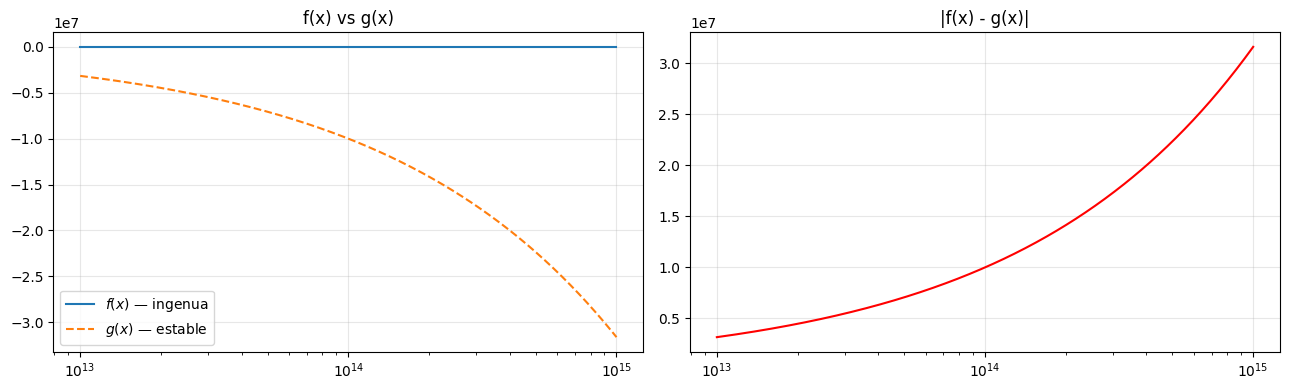

In [ ]:
import matplotlib.pyplot as plt

x_vals = np.logspace(13, 15, 500)

def f_ingenua(x):
    return np.sqrt(x + 1) - np.sqrt(x)

def g_estable(x):
    # - su codigo aqui -
    return (np.sqrt(x+1) - np.sqrt(x))/(x+1-x)
    # -

y_f = f_ingenua(x_vals)
y_g = g_estable(x_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(x_vals, y_f, label=r'$f(x)$ — ingenua')
axes[0].semilogx(x_vals, y_g, '--', label=r'$g(x)$ — estable')
axes[0].set_title('f(x) vs g(x)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].semilogx(x_vals, np.abs(y_f - y_g), color='red')
axes[1].set_title('|f(x) - g(x)|'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

📝 **Análisis:** *Explique aquí el fenomeno de cancelacion catastrofica observado y por qué $g(x)$ lo evita.*

---
## Ejercicio 2 — Sistemas de Ecuaciones Lineales

### Recordatorio: Factorizacion LU y sustitucion

Dada $A = LU$, el sistema $Ax = b$ se resuelve en dos etapas:

**Paso 1 — Sustitucion progresiva:** resolver $Ly = b$
$$y_i = b_i - \sum_{j=1}^{i-1} L_{ij}\,y_j, \quad i = 1, \ldots, n$$

**Paso 2 — Sustitucion regresiva:** resolver $Ux = y$
$$x_i = \frac{1}{U_{ii}}\!\left(y_i - \sum_{j=i+1}^{n} U_{ij}\,x_j\right), \quad i = n, \ldots, 1$$

El coste es $O(n^2)$ una vez que la factorizacion esta disponible, frente a $O(n^3)$ si se calculara la inversa .

### Parte a — Resolver $Ax = b$ usando la factorizacion LU &nbsp;*(teorico)*

> 📝 Esta parte puede desarrollarse con **lápiz y papel**. Adjunte su desarrollo al comprimido de entrega.

Se tiene el sistema $Ax = b$ con la factorizacion $A = LU$:

$$L = \begin{pmatrix} 1 & 0 & 0 \\ 2 & 1 & 0 \\ 1 & 3 & 1 \end{pmatrix}, \quad U = \begin{pmatrix} 2 & 4 & 2 \\ 0 & 2 & 4 \\ 0 & 0 & 2 \end{pmatrix}, \quad b = \begin{pmatrix} 2 \\ 8 \\ 12 \end{pmatrix}$$

**Sin calcular ninguna inversa**, resuelva el sistema mediante sustitucion progresiva ($Ly = b$) y regresiva ($Ux = y$). Muestre cada paso analíticamente.

Luego, verifique su resultado implementando las funciones de sustitucion en Python.

📝 **Desarrollo manual (Parte a):**

**Sustitucion progresiva — $Ly = b$:**

$y_1 = \ldots$

$y_2 = \ldots$

$y_3 = \ldots$

---

**Sustitucion regresiva — $Ux = y$:**

$x_3 = \ldots$

$x_2 = \ldots$

$x_1 = \ldots$

**Solucion:** $x = (\ldots,\;\ldots,\;\ldots)^T$

In [11]:
L = np.array([[1, 0, 0], [2, 1, 0], [1, 3, 1]], dtype=float)
U = np.array([[2, 4, 2], [0, 2, 4], [0, 0, 2]], dtype=float)
b = np.array([2, 8, 12], dtype=float)

def sustitucion_progresiva(L, b):
    """Resuelve Ly = b (L triangular inferior con unos en diagonal)."""
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        # - su codigo aqui -
        pass
    return y

def sustitucion_regresiva(U, y):
    """Resuelve Ux = y (U triangular superior)."""
    n = len(y)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        # - su codigo aqui -
        pass
    return x

y_sol = sustitucion_progresiva(L, b)
x_sol = sustitucion_regresiva(U, y_sol)

print("Vector intermedio y =", y_sol)
print("Solucion x          =", x_sol)
print("Residuo  Ax - b     =", np.round(L @ U @ x_sol - b, 10))
print("\nVerificacion con np.linalg.solve:", np.linalg.solve(L @ U, b))

Vector intermedio y = [0. 0. 0.]
Solucion x          = [0. 0. 0.]
Residuo  Ax - b     = [ -2.  -8. -12.]

Verificacion con np.linalg.solve: [-6.  4. -1.]


### Parte b — Problema real: fábrica de muebles

Una pequeña fábrica produce tres tipos de muebles: **sillas**, **mesas** y **estantes**. Para fabricar cada uno se consumen distintas cantidades de tres materiales:

| Producto | Madera (unidades) | Tornillos (unidades) | Pintura (litros) |
|----------|-------------------|----------------------|------------------|
| Silla    | 3                 | 2                    | 1                |
| Mesa     | 1                 | 4                    | 2                |
| Estante  | 2                 | 1                    | 5                |

Al cierre de una semana de produccion se comprueba que se consumieron en total: **17 unidades de madera**, **20 tornillos** y **28 litros de pintura**.

**¿Cuántas unidades de cada tipo de mueble se fabricaron esa semana?**

Para resolverlo:
1. Identifique y escriba el sistema de 3 ecuaciones con 3 incognitas (sillas $s$, mesas $m$, estantes $e$).
2. Construya la matriz de coeficientes $A$ y el vector de términos independientes $b$.
3. Resuelva con `numpy.linalg.solve`.

📝 **Sistema de ecuaciones (complete aquí):**

Ecuacion 1 (madera):     $\ldots s + \ldots m + \ldots e = \ldots$

Ecuacion 2 (tornillos):  $\ldots s + \ldots m + \ldots e = \ldots$

Ecuacion 3 (pintura):    $\ldots s + \ldots m + \ldots e = \ldots$

In [12]:
# - su codigo aqui — construya A y b a partir del sistema de ecuaciones -
A = np.array([
    [...],   # coeficientes de la ecuacion 1
    [...],   # coeficientes de la ecuacion 2
    [...],   # coeficientes de la ecuacion 3
], dtype=float)

b2 = np.array([...], dtype=float)  # vector de terminos independiente
# -

# su codigo aqui resuelva el sistema 
x_muebles = None
# -

print("Produccion semanal:")
print(f"  Sillas:   {x_muebles[0]:.1f} unidades")
print(f"  Mesas:    {x_muebles[1]:.1f} unidades")
print(f"  Estantes: {x_muebles[2]:.1f} unidades")
print("\nVerificacion A @ x - b:", np.round(A @ x_muebles - b2, 10))

TypeError: float() argument must be a string or a real number, not 'ellipsis'

---
## Ejercicio 3 — Ecuacion No Lineal

### Recordatorio: Método de Newton

El **método de Newton-Raphson** genera la sucesion:
$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$$

converge **cuadraticamente** cerca de una raíz simple. En `scipy`:
```python
from scipy.optimize import newton
raiz = newton(f, x0, fprime=df)   # fprime es opcional
```

**Buena práctica:** grafique primero para estimar los puntos iniciales $x_0$.

### Enunciado

Encuentre todas las raíces reales de:
$$f(x) = e^{-x/3}\cos(2x) - 0.3, \quad x \in [0,\, 10]$$

Esta funcion modela la amplitud de una **oscilacion amortiguada** que cruza cierto umbral de deteccion. Cada cruce con el eje horizontal es un instante critico.

Su derivada analítica es:
$$f'(x) = -\tfrac{1}{3}e^{-x/3}\cos(2x) - 2e^{-x/3}\sin(2x)$$

**a)** Grafique $f(x)$ en $[0, 10]$ e identifique visualmente los intervalos donde hay raíces.

**b)** Use `scipy.optimize.newton` con la derivada analítica para hallar **todas** las raíces. Verifique que $|f(\text{raíz})| < 10^{-9}$.

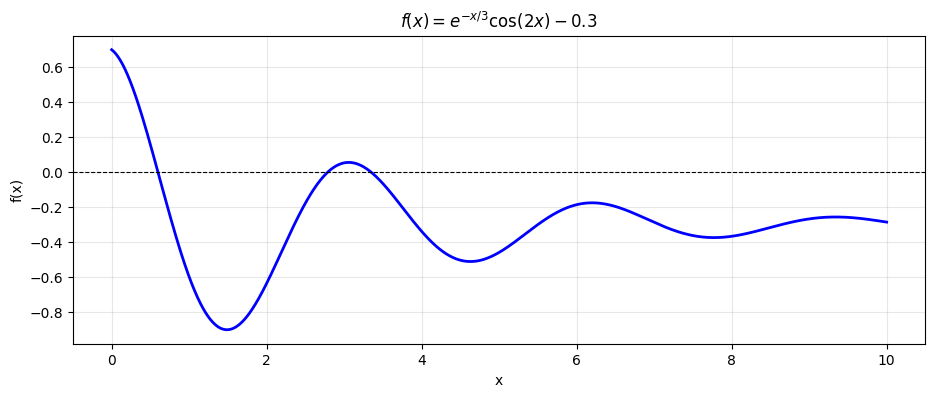

In [13]:
def f3(x):
    return np.exp(-x / 3) * np.cos(2 * x) - 0.3

def df3(x):
    return (-1/3)*np.exp(-x/3)*np.cos(2*x) - 2*np.exp(-x/3)*np.sin(2*x)

# Parte a: Grafico
x_plot = np.linspace(0, 10, 1000)
plt.figure(figsize=(11, 4))
plt.plot(x_plot, f3(x_plot), 'b-', linewidth=2)
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title(r'$f(x)=e^{-x/3}\cos(2x)-0.3$')
plt.grid(True, alpha=0.3); plt.show()

In [14]:
# Parte b: Busqueda de raices
# su codigo aqui — identifique puntos iniciales a partir del gráfico
x0_lista = [...]   # complete con sus estimaciones iniciales

raices = []
for x0 in x0_lista:
    # - su codigo aqui — use optimize.newton para cada x0 
    pass

raices.sort()
print(f"Raíces encontradas en [0, 10]: {len(raices)}\n")
print(f"{'#':>3} | {'Raíz':>14} | {'f(raíz)':>12} | OK?")
print("-" * 42)
for i, r in enumerate(raices):
    ok = 'sí' if abs(f3(r)) < 1e-9 else 'NO'
    print(f"{i+1:>3} | {r:>14.10f} | {f3(r):>12.2e} | {ok}")

Raíces encontradas en [0, 10]: 0

  # |           Raíz |      f(raíz) | OK?
------------------------------------------


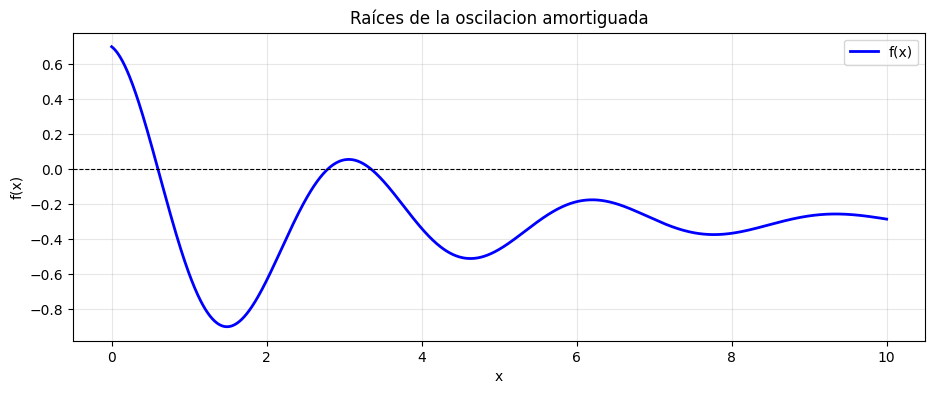

In [15]:
# Grafico con raices marcadas
plt.figure(figsize=(11, 4))
plt.plot(x_plot, f3(x_plot), 'b-', linewidth=2, label='f(x)')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
if raices:
    plt.scatter(raices, [f3(r) for r in raices],
                color='red', zorder=5, s=80, label='Raíces')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Raíces de la oscilacion amortiguada')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

---
## Ejercicio 4 — Interpolacion

### Recordatorio teorico

#### Polinomio de Lagrange

Dado un conjunto de $n+1$ nodos $\{x_0,\ldots,x_n\}$ y valores $\{y_0,\ldots,y_n\}$:
$$p_n(x) = \sum_{i=0}^{n} y_i\,L_i(x), \qquad L_i(x) = \prod_{j\neq i}\frac{x-x_j}{x_i-x_j}$$

Existe un **único** polinomio de grado $\leq n$ que pasa por los $n+1$ nodos. Con muchos nodos no equiespaciados puede presentar **oscilaciones de Runge** cerca de los bordes.

#### Splines cúbicos

En lugar de un único polinomio global, se usa un cúbico $S_i(x)$ por cada subintrevalo $[x_i, x_{i+1}]$, garantizando:
- Interpolacion exacta en los nodos
- Continuidad de $S$, $S'$ y $S''$ (clase $C^2$)

Resultado: curva globalmente **suave** que evita las oscilaciones del Lagrange de alto grado.

### Enunciado

La siguiente tabla muestra mediciones de **concentracion de CO₂** (ppm) en la atmosfera a lo largo del año:

| Mes | 0 | 2 | 4 | 5 | 7 | 9 | 11 | 12 |
|-----|---|---|---|---|---|---|-------|----|
| CO₂ (ppm) | 380 | 410 | 450 | 462 | 460 | 430 | 395 | 380 |

**a)** Use `scipy.interpolate.lagrange` para construir el polinomio de Lagrange y estime el CO₂ en el **mes 6**.

**b)** Use `scipy.interpolate.CubicSpline` para construir el spline cúbico y estime el CO₂ en el **mes 6**.

**c)** Grafique ambos interpolantes junto con los datos originales. Explique cuál es más adecuado para este problema y por qué.

In [16]:
from scipy.interpolate import lagrange, CubicSpline

meses = np.array([0, 2, 4, 5, 7, 9, 11, 12], dtype=float)
co2   = np.array([380, 410, 450, 462, 460, 430, 395, 380], dtype=float)

x_fino  = np.linspace(0, 12, 600)
mes_pred = 6

# - Parte a: Polinomio de Lagrange -
p_lagrange = lagrange(meses, co2)

# - su codigo aqui -
y_lagrange     = None   # evalue p_lagrange en x_fino
co2_lagrange_6 = None   # prediccion en mes 6
# -

print(f"Lagrange — prediccion mes {mes_pred}: {co2_lagrange_6} ppm")

Lagrange — prediccion mes 6: None ppm


In [17]:
# - Parte b: Spline cúbico -
# - su codigo aqui -
cs          = None   # construya el CubicSpline
y_spline    = None   # evalue en x_fino
co2_spline_6 = None  # prediccion en mes 6
# -

print(f"Spline cúbico — prediccion mes {mes_pred}: {co2_spline_6} ppm")

Spline cúbico — prediccion mes 6: None ppm


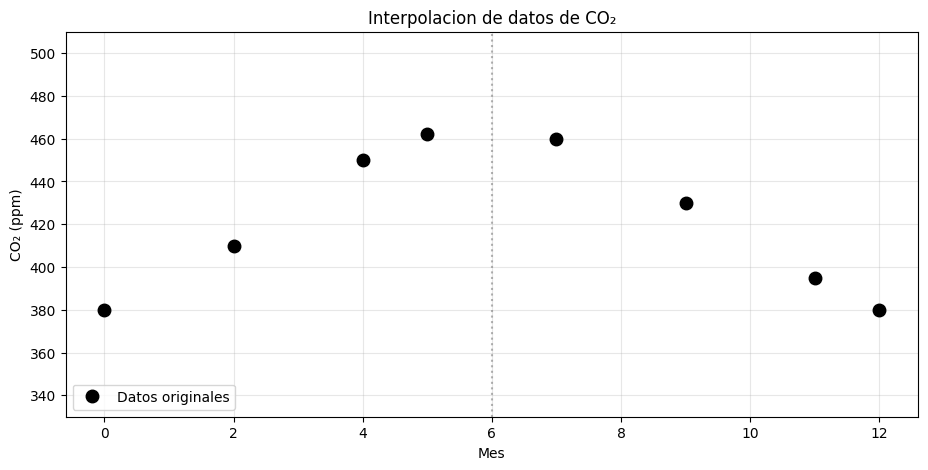

In [18]:
# - Parte c: Grafico comparativo -
plt.figure(figsize=(11, 5))
plt.plot(meses, co2, 'ko', markersize=9, zorder=5, label='Datos originales')
if y_lagrange is not None:
    plt.plot(x_fino, y_lagrange, 'b-', linewidth=2, label='Lagrange')
    plt.scatter([mes_pred], [co2_lagrange_6], color='blue', s=100, zorder=6)
if y_spline is not None:
    plt.plot(x_fino, y_spline, 'r--', linewidth=2, label='Spline cúbico')
    plt.scatter([mes_pred], [co2_spline_6], color='red', marker='D', s=100, zorder=6)
plt.axvline(mes_pred, color='gray', linestyle=':', alpha=0.6)
plt.xlabel('Mes'); plt.ylabel('CO₂ (ppm)')
plt.title('Interpolacion de datos de CO₂')
plt.legend(loc='lower left'); plt.grid(True, alpha=0.3)
plt.ylim(330, 510); plt.show()

📝 **Análisis (Parte c):** *Compare los dos interpolantes. ¿Observa oscilaciones de Runge en el Lagrange? ¿Cuál elegiría para datos reales con muchos puntos? Justifique.*

---
## Ejercicio 5 — Regresion Lineal

### Recordatorio: Mínimos Cuadrados

El modelo lineal $y \approx \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots$ se ajusta construyendo la **matriz de diseño** $X$:

$$X = \begin{pmatrix} 1 & x_1^{(1)} & x_2^{(1)} \\ 1 & x_1^{(2)} & x_2^{(2)} \\ \vdots & \vdots & \vdots \end{pmatrix}$$

El vector $\hat{\beta}$ que minimiza $\|X\hat{\beta}-y\|^2$ satisface la **ecuacion normal**:
$$(X^\top X)\,\hat{\beta} = X^\top y$$

Se resuelve como sistema lineal — **nunca** calculando $(X^\top X)^{-1}$:
```python
beta = np.linalg.solve(X.T @ X,  X.T @ y)
```

**¿Como se forman $X^\top X$ y $X^\top y$?** Si $X = [\mathbf{1} \mid \mathbf{x}_1 \mid \mathbf{x}_2]$:

$$X^\top X = \begin{pmatrix} n & \sum x_1 & \sum x_2 \\ \sum x_1 & \sum x_1^2 & \sum x_1 x_2 \\ \sum x_2 & \sum x_1 x_2 & \sum x_2^2 \end{pmatrix}, \qquad X^\top y = \begin{pmatrix} \sum y \\ \sum x_1 y \\ \sum x_2 y \end{pmatrix}$$

### Enunciado

Se dispone de datos sobre el rendimiento académico de 30 estudiantes de Ciencia de Datos:
- $x_1$: horas de estudio teorico por semana
- $x_2$: horas de práctica en computadora por semana
- $y$: nota en el examen final (escala 0–30)

El modelo subyacente que genero los datos es $y = 5 + 2x_1 + 3x_2 + \varepsilon$ con $\varepsilon \sim \mathcal{N}(0,\,1.5)$ — este modelo es *desconocido* para el estudiante en el contexto del ejercicio.

**a)** Ajuste un modelo de **1 variable** ($x_1$): construya $X_1$, resuelva la ecuacion normal, grafique la recta ajustada.

**b)** Ajuste un modelo de **2 variables** ($x_1$, $x_2$): extienda $X$ a 3 columnas, resuelva la ecuacion normal, compare el MSE con el modelo anterior.

**c)** Grafique en 3D los datos y el plano ajustado del modelo de 2 variables.

In [19]:
# Datos (semilla fija para reproducibilidad)
np.random.seed(42)
n_datos = 30
x1_datos = np.random.uniform(1, 8, n_datos)
x2_datos = np.random.uniform(0.5, 4, n_datos)
y_datos  = 5 + 2*x1_datos + 3*x2_datos + np.random.normal(0, 1.5, n_datos)
y_datos  = np.clip(y_datos, 0, 30)

print("Muestra de los datos (primeras 6 filas):")
print(f"{'#':>3} | {'x1 (estudio h/sem)':>18} | {'x2 (practica h/sem)':>19} | {'y (nota)':>8}")
print("-" * 56)
for i in range(6):
    print(f"{i+1:>3} | {x1_datos[i]:>18.3f} | {x2_datos[i]:>19.3f} | {y_datos[i]:>8.3f}")

Muestra de los datos (primeras 6 filas):
  # | x1 (estudio h/sem) | x2 (practica h/sem) | y (nota)
--------------------------------------------------------
  1 |              3.622 |               2.626 |   17.905
  2 |              7.655 |               1.097 |   22.521
  3 |              6.124 |               0.728 |   18.740
  4 |              5.191 |               3.821 |   28.430
  5 |              2.092 |               3.880 |   21.339
  6 |              2.092 |               3.329 |   16.528


In [20]:
# - Parte a: Regresion con 1 variable -
# - su codigo aqui -
X1   = None   # matriz de diseno [1 | x1]  — shape (30, 2)
XtX1 = None   # X1.T @ X1
Xty1 = None   # X1.T @ y_datos
beta1 = None  # resuelva la ecuacion normal  (NO usar np.linalg.inv)
# -

y_pred1 = X1 @ beta1
mse1    = np.mean((y_datos - y_pred1)**2)

print(f"β₀ = {beta1[0]:.4f},  β₁ = {beta1[1]:.4f}")
print(f"Modelo: y = {beta1[0]:.3f} + {beta1[1]:.3f}·x1")
print(f"MSE (1 variable): {mse1:.4f}")

x1_plot = np.linspace(x1_datos.min(), x1_datos.max(), 100)
plt.figure(figsize=(7, 5))
plt.scatter(x1_datos, y_datos, alpha=0.7, label='Datos')
plt.plot(x1_plot, beta1[0] + beta1[1]*x1_plot, 'r-', linewidth=2,
         label=f'Recta ajustada')
plt.xlabel('Horas de estudio (x1)'); plt.ylabel('Nota (y)')
plt.title('Regresion lineal — 1 variable')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

TypeError: unsupported operand type(s) for @: 'NoneType' and 'NoneType'

In [21]:
# - Parte b: Regresion con 2 variables -
# - su codigo aqui -
X2    = None   # matriz de diseno [1 | x1 | x2]  — shape (30, 3)
XtX2  = None
Xty2  = None
beta2 = None   # resuelva la ecuacion normal
# -

y_pred2 = X2 @ beta2
mse2    = np.mean((y_datos - y_pred2)**2)

print(f"β₀={beta2[0]:.4f}, β₁={beta2[1]:.4f}, β₂={beta2[2]:.4f}")
print(f"Modelo: y = {beta2[0]:.3f} + {beta2[1]:.3f}·x1 + {beta2[2]:.3f}·x2")
print(f"\nMSE (1 variable):  {mse1:.4f}")
print(f"MSE (2 variables): {mse2:.4f}")
print(f"Mejora al incluir x2: {100*(mse1-mse2)/mse1:.1f}%")

TypeError: unsupported operand type(s) for @: 'NoneType' and 'NoneType'

TypeError: 'NoneType' object is not subscriptable

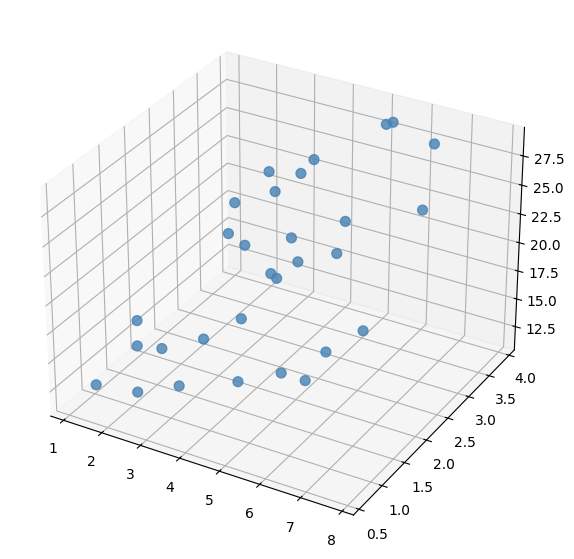

In [22]:
# - Parte c: Visualizacion 3D -
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(x1_datos, x2_datos, y_datos, c='steelblue', alpha=0.8, s=50,
           label='Datos reales')

x1_m = np.linspace(x1_datos.min(), x1_datos.max(), 25)
x2_m = np.linspace(x2_datos.min(), x2_datos.max(), 25)
X1m, X2m = np.meshgrid(x1_m, x2_m)
Y_plano  = beta2[0] + beta2[1]*X1m + beta2[2]*X2m
ax.plot_surface(X1m, X2m, Y_plano, alpha=0.35, color='tomato')
ax.set_xlabel('Horas estudio (x1)')
ax.set_ylabel('Horas práctica (x2)')
ax.set_zlabel('Nota (y)')
ax.set_title('Regresion lineal — 2 variables')
plt.tight_layout(); plt.show()

---
## ⭐ Ejercicio Extra 1 — Método de Newton desde cero

> Estos ejercicios no son necesarios para aprobar, pero son **imprescindibles** para alcanzar la calificacion de **4 o 5**.

Implemente el método de Newton-Raphson para $f\colon\mathbb{R}\to\mathbb{R}$ **sin usar `scipy`**, solo NumPy.

Su funcion `newton_scratch` debe:
- Iterar $x_{k+1} = x_k - f(x_k)/f'(x_k)$
- Parar cuando $|x_{k+1} - x_k| < \text{tol}$
- Avisar (con `print`) si $|f'(x_k)| < 10^{-12}$ (posible raíz múltiple)
- Retornar la raíz, el número de iteraciones y el array de todos los $x_k$

Pruébela con $f(x) = e^{-x/3}\cos(2x) - 0.3$ del Ejercicio 3 y compare con `scipy.optimize.newton`. Grafique la convergencia.

In [23]:
def newton_scratch(f, df, x0, tol=1e-10, max_iter=100):
    """
    Método de Newton-Raphson para f: R -> R.
    Parametros: f, df, x0, tol, max_iter
    Retorna: (raiz, n_iteraciones, array_historia_xk)
    """
    # - su codigo aqui -
    pass
    # -

# Prueba
x0_prueba = 0.4
raiz_s, iters_s, hist_s = newton_scratch(f3, df3, x0_prueba)
raiz_scipy = optimize.newton(f3, x0_prueba, fprime=df3, tol=1e-12)

print(f"Newton manual:  {raiz_s:.12f}  ({iters_s} iters)")
print(f"scipy.newton:   {raiz_scipy:.12f}")
print(f"Diferencia:     {abs(raiz_s - raiz_scipy):.2e}")

plt.figure(figsize=(8, 4))
plt.semilogy(range(len(hist_s)), np.abs(hist_s - raiz_s), 'bo-', markersize=5)
plt.xlabel('Iteracion k'); plt.ylabel('|x_k − raíz|')
plt.title('Convergencia del método de Newton (implementacion manual)')
plt.grid(True, alpha=0.3); plt.show()

TypeError: cannot unpack non-iterable NoneType object

---
## ⭐ Ejercicio Extra 2 — Regresion lineal *n* variables desde cero

> Estos ejercicios no son necesarios para aprobar, pero son **imprescindibles** para alcanzar la calificacion de **4 o 5**.

Implemente `regresion_lineal(X, y)` para **cualquier número de variables** predictoras usando solo NumPy:
- Construya $X^\top X$ y $X^\top y$
- Resuelva $(X^\top X)\hat{\beta} = X^\top y$ con `np.linalg.solve` (**sin inversa**)
- Retorne $\hat{\beta}$ y el MSE del ajuste

Verifique que reproduce exactamente los resultados del Ejercicio 5 para 1 y 2 variables.

In [24]:
def regresion_lineal(X, y):
    """
    Regresion lineal por mínimos cuadrados.
    Resuelve (X^T X) beta = X^T y sin calcular ninguna inversa.

    Parametros
    ----------
    X : ndarray (n_muestras, n_features)  — debe incluir columna de unos
    y : ndarray (n_muestras,)

    Retorna
    -------
    beta : ndarray (n_features,)
    mse  : float
    """
    # - su codigo aqui -
    pass
    # -

# Verificacion con los datos del Ejercicio 5
beta_v1, mse_v1 = regresion_lineal(X1, y_datos)
beta_v2, mse_v2 = regresion_lineal(X2, y_datos)

print("Verificacion 1 variable:")
print(f"  beta coincide: {np.allclose(beta_v1, beta1)}")
print(f"  MSE coincide:  {np.isclose(mse_v1, mse1)}")
print("\nVerificacion 2 variables:")
print(f"  beta coincide: {np.allclose(beta_v2, beta2)}")
print(f"  MSE coincide:  {np.isclose(mse_v2, mse2)}")

TypeError: cannot unpack non-iterable NoneType object

---
*Evaluacion Final — Matemática Numérica · MATCOM · Ciencia de Datos · 2025-2026*  
**Fecha de entrega: 17 de junio de 2026** — Entregue el comprimido (.zip) con el notebook y los desarrollos teoricos en papel.